## ROC

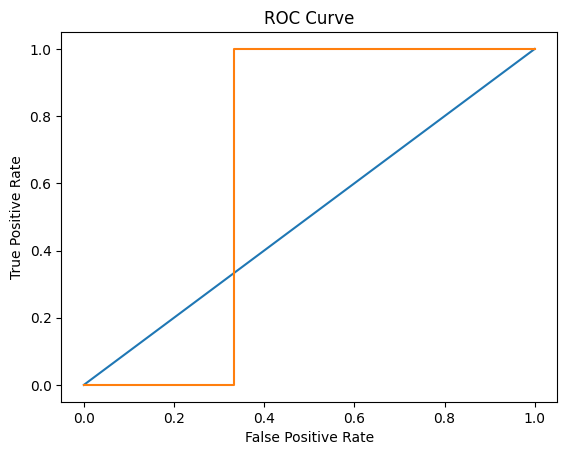

0.6666666666666666

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

comp_prob=pd.read_csv('comp_prob.csv')
y_prod_probs1=comp_prob['yprob_1']
y_prod_probs2=comp_prob['yprob_2']
y_test=comp_prob['y_test']
fpr,tpr,thresholds=roc_curve(y_test,y_prod_probs1)
plt.plot([0,1],[0,1])
plt.plot(fpr,tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()
roc_auc_score(y_test,y_prod_probs1)

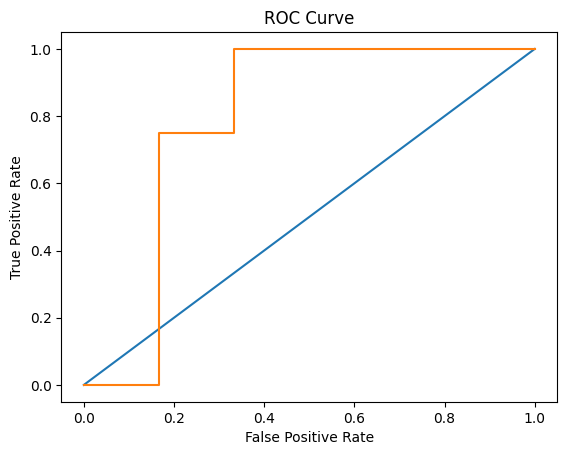

0.7916666666666666

In [2]:
fpr,tpr,thresholds=roc_curve(y_test,y_prod_probs2)
plt.plot([0,1],[0,1])
plt.plot(fpr,tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()
roc_auc_score(y_test,y_prod_probs2)

In [3]:
comp_prob.head()

,y_test,yprob_1,yprob_2
0,1,0.6,0.70
1,1,0.4,0.45
2,0,0.8,0.90
3,0,0.2,0.20
4,0,0.3,0.15


C:\Users\dai\PycharmProjects\ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


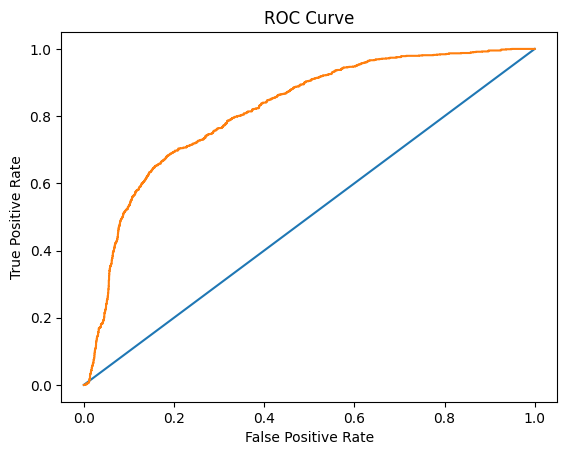

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
hr=pd.read_csv('HR_comma_sep.csv')
dum_hr=pd.get_dummies(hr,drop_first=True)
x=dum_hr.drop('left',axis=1)
y=dum_hr['left']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=25,stratify=y )
lr=LogisticRegression()
lr.fit(x_train,y_train)
y_pred_prob=lr.predict_proba(x_test)
fpr,tpr,thresholds=roc_curve(y_test,y_pred_prob[:,1])
plt.plot([0,1],[0,1])
plt.plot(fpr,tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [5]:
from sklearn.metrics import accuracy_score
solver=['sag','newton-cholesky','newton-cg','lbfgs']
penalties=['l2',None]
scores=[]
for p in penalties:
    for s in solver:
        lr=LogisticRegression(penalty=p,solver=s)
        lr.fit(x_train,y_train)
        y_pred_prob=lr.predict_proba(x_test)[:,1]
        roc_auc=roc_auc_score(y_test,y_pred_prob)
        scores.append([p,s,roc_auc])
df_scores=pd.DataFrame(scores,columns=['penalty','solver','roc_auc'])
df_scores.sort_values('roc_auc',ascending=False)

C:\Users\dai\PycharmProjects\ML\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\dai\PycharmProjects\ML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\dai\PycharmProjects\ML\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\dai\Pych

,penalty,solver,roc_auc
2,l2,newton-cg,0.822300
1,l2,newton-cholesky,0.822268
5,None,newton-cholesky,0.822144
6,None,newton-cg,0.822140
7,None,lbfgs,0.816266
3,l2,lbfgs,0.815986
4,None,sag,0.810092
0,l2,sag,0.810051


In [6]:
import pandas as pd
import numpy as np
from numpy.random import logistic
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
hr=pd.read_csv('HR_comma_sep.csv')
dum_hr=pd.get_dummies(hr,drop_first=True)
x=dum_hr.drop('left',axis=1)
y=dum_hr['left']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=25,stratify=y )
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=25, stratify=y)
scores = []
k=[1,2,3,4,5,6,7,8,9,10]
ss=StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=25, stratify=y)
X_trn_ss = ss.fit_transform(X_train)
X_tst_ss = ss.transform(X_test)
scores = []
for k in k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_trn_ss, y_train)
    y_pred_prob = knn.predict_proba(X_tst_ss)
    scores.append([k,roc_auc_score(y_test, y_pred_prob[:,1])])

scores = pd.DataFrame(scores, columns=["k", "score"])
scores.sort_values("score", ascending=False)

,k,score
4,5,0.976023
8,9,0.975783
5,6,0.975670
6,7,0.975559
7,8,0.975373
9,10,0.975260
2,3,0.975210
3,4,0.974600
1,2,0.971977
0,1,0.963983


In [7]:
scores = []
k = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=25, stratify=y)
scores = []
for k in k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_prob = knn.predict_proba(X_test)
    scores.append([k, roc_auc_score(y_test, y_pred_prob[:, 1])])

scores = pd.DataFrame(scores, columns=["k", "score"])
scores.sort_values("score", ascending=False)


,k,score
7,8,0.974952
6,7,0.974829
8,9,0.974618
9,10,0.974376
5,6,0.974021
4,5,0.972944
3,4,0.971020
2,3,0.969717
1,2,0.963969
0,1,0.948632


## Log Loss

In [9]:
from sklearn.metrics import log_loss

comp_prob=pd.read_csv('comp_prob.csv')
y_prod_probs1=comp_prob['yprob_1']
y_prod_probs2=comp_prob['yprob_2']
y_test=comp_prob['y_test']
log_loss(y_test,y_prod_probs1)

0.6960811811170735

In [10]:
log_loss(y_test,y_prod_probs2)

0.6052889328967097